### Example: a radiative sheet with FLD

In this example we will use ```pyFLD``` to solve the pair of equations

$$\frac{\partial e}{\partial t} = - \kappa_\mathrm{P}\rho c\left(a_\mathrm{R}{T^4} - E_\mathrm{rad}\right)$$
$$\frac{\partial E_\mathrm{rad}}{\partial t} - \nabla\cdot\left(\frac{\lambda c}{\rho\kappa_\mathrm{R}}\nabla E_\mathrm{rad}\right) = \kappa_\mathrm{P}\rho c\left(a_\mathrm{R}T^4 - E_\mathrm{rad}\right)$$

until equilibrium ($\partial/\partial t=0$). In Cartesian 1D, and with a constant flux limiter $\lambda$, this greatly simplifies to

$$\nabla\cdot\left(\frac{\lambda c}{\rho\kappa_\mathrm{R}}\nabla E_\mathrm{rad}\right) = 0\Rightarrow \frac{\partial E_\mathrm{rad}}{\partial x} = b,$$

 $E_\mathrm{rad}(x) = E_\mathrm{L} + \left(E_\mathrm{R}-E_\mathrm{L}\right) x$meaning that if we choose two boundary values for $E_\mathrm{rad}$ on the left and right of the box we simply have that

$$E_\mathrm{rad}(x) = E_\mathrm{L} + \frac{E_\mathrm{R}-E_\mathrm{L}}{x_\mathrm{R}-x_\mathrm{L}} (x-x_\mathrm{L}).$$

First, we import the required libraries. We need ```numpy``` for general data handling, ```matplotlib``` for plotting, and ```astropy``` to handle unit conversions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const, units as u

import pyFLD as fld

To use ```pyFLD``` we need to define
+ a grid
+ at least one fluid
+ a radiative environment that solves the FLD equations for our fluid(s)

### Grid

To create a grid, we define 3 1D arrays that include ghost cells (so that we can take gradients beyond the active domain) and pass them to the Grid constructor of ```pyFLD```.

Note that a 1-cell array is needed even if you don't intend to solve along that direction. ```pyFLD``` will simply not solve along directions with only 1 cell, but the internal code structure is always spatially 3D:

In [2]:
xi = fld.grid.get_domain_with_ghosts(1, 2, Nx=100) * u.cm
yi = fld.grid.get_domain_with_ghosts(0, 1, Nx=1) * u.cm
zi = fld.grid.get_domain_with_ghosts(0, 1, Nx=1) * u.cm
grid = fld.grid.Grid(xi, yi, zi, geometry='cartesian')

Note: The grid will have a shape $(N_z, N_y, N_x)$, including ghost cells in all directions. This helps a lot with calculations internally (especially for non-Cartesian geometries). For example, since this is a 1D problem, and we have 2 ghost cells on either side, the actual grid shape should be $5\times 5\times 104$ cells:

In [3]:
grid.shape

(5, 5, 104)

To help with this, the ```grid``` object includes "slicers" along any direction that can help you pick out the active segment of the domain:

- ```grid.act1``` for the `x1` direction (here $x$)
- ```grid.act2``` for the `x2` direction (here $y$)
- ```grid.act3``` for the `x3` direction (here $z$)
- ```grid.active``` to cut out all ghost cells

The actual "active" domain then has the expected shape of $1\times 1\times 100$ cells (since $x$ is the last index)

In [4]:
grid.active_shape

(1, 1, 100)

### Fluid(s)

Next, we create a fluid object. We'll use a "gas" object ("dust" objects behave the same way in this example) and give it a simple (optional) name.

The fluid object also needs to know about the grid information.

In [5]:
Gas = fld.fluids.Gas(grid=grid, name='basic')

From this point on, the ```grid``` object has been propagated into the ```Gas``` object as ```Gas.grid```. This means that editing one will affect the other!

Next, this object needs a density $\rho$ and temperature $T$. We can use the grid object to compute this.

Again, these should be 3D arrays. For this problem we'll use a constant density.

```pyFLD``` expects all quantities to be passed in appropriate units, i.e., density must be an ```astropy.Quantity``` object with units [mass] / [length]^3 or equivalent.



In [6]:
E0  = 1 * u.erg / u.cm**3 # an arbitrary radiation energy
rho = 1 * u.g/u.cm**3 * np.ones(grid.shape) # ρ = 1 g/cm3
tmp = fld.tools.Er_to_T(E0) * np.ones(grid.shape) # T = T0 (set by E0), in K

# Now set them in the Gas object.
Gas.set_density(rho)
Gas.set_temperature(tmp)

We also need to define opacities for the gas. For this example we'll set a constant value for both Rosseland and Planck mean opacities by defining a function that expects the fluid object itself and returns a value (or array) of the opacity as a function of fluid properties (here ignored, since the opacity is constant):

In [7]:
def get_kappa(fluid): return 1.0 * u.cm**2/u.g
Gas.enroll_kappaR(get_kappa)
Gas.enroll_kappaP(get_kappa)

Finally, call the ```setup()``` method to compute everything else internally

In [8]:
Gas.setup()

In principle you can repeat these steps as many times as you want, for as many fluids as you'd like, each having their own densities and opacities (but all sharing the same temperature!). Next, we will define a radiative environment that combines these fluids to solve the above equations.

### Radiative environment

This object expects the list of fluids as its main argument (in this case a list with 1 element, our ```Gas``` object). It can also have a name, for debugging purposes.

For this problem, since we want a constant $\lambda=1/3$ (diffusion limit), we need to explicitly state this when creating the environment:

In [9]:
Box = fld.FLD.RadiativeEnvironment([Gas], name='box', constant_fluxlimiter=True, verbose=False)

Finally, we need to tell the FLD object how to handle boundary conditions for any quantity.

For this we need to set the behavior of each side, ordered as: $x_\mathrm{beg}$, $x_\mathrm{end}$, $y_\mathrm{beg}$, $y_\mathrm{end}$, $z_\mathrm{beg}$, $z_\mathrm{end}$.

The currently supported options are zero-gradient ("reflective") or fixed value for $E_\mathrm{rad}$.

Since we want our problem setup to be 1D in $x$, we'll choose:
- fixed-value along $x$ with $E_\mathrm{L} = E_0$, $E_\mathrm{R} = 2 E_0$
- reflective along all other directions

In [10]:
val, ref = fld.grid.BOUNDARY_FIXEDVALUE, fld.grid.BOUNDARY_REFLECTIVE
bounds = [val, val, ref, ref, ref, ref] # xbeg, xend, ybeg, yend, zbeg, zend
vals   = [E0, 2*E0, 0, 0, 0, 0]
Box.declare_boundaries(bounds, vals)

We are now ready to go!

Before any solving, let's plot the ```Box``` state. For this, we can use the slicers "act1/2/3" or "active" to select the active domain in 1D quantities in the x1/2/3 directions, or 3D quantities, respectively.

Note that the ```grid``` arrays ($x$, $y$, $z$) also contain length-related units! For the purposes of plotting, we'll trim them out as we load the arrays. In general, however, you might want to keep the unit information.

Some general rules of thumb when using ```astropy.units```:

- `a = 1 * u.cm`, `b = 10 * u.cm` $\rightarrow$ `a` and `b` are `astropy` `Quantity` objects with "length" units
- `a.to('5 au')` $\rightarrow$ expresses `a` in a different length unit (here 5 au)
- `a.to_value('25 pc')` $\rightarrow$ expresses `a` as a float in the target length unit (i.e., strips the unit information)
-  `(a/b).to_value('')` $\rightarrow$ evaluates `a/b`, then converts their ratio to a float with no units, as expected
- `a.to('GHz')` or `(a/b).to_value('au')` $\rightarrow$ will result in errors

Anyway, let's load the $x$ array, and also define a helper function that trims the ghost cells and selects the only part we care about: the 1D $x$ array. For this, we simply take the only element in $z$ and $y$:

In [11]:
x = grid.x1[grid.act1].to_value('cm')

def fmt(qty3D): return 1 * qty3D[grid.active][0][0]

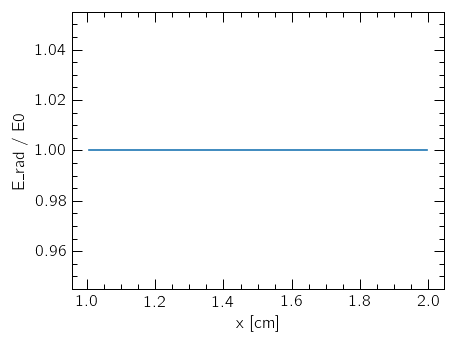

In [12]:
fig, ax = plt.subplots(figsize=(4, 3), dpi=120)

ax.plot(x, fmt(Box.Er).to_value(E0))

ax.set_xlabel('x [cm]')
ax.set_ylabel('E_rad / E0')

plt.show()

Pretty boring, but it's exactly what we ordered: a constant radiation energy (defined through $T$).

Now we'll perform some steps with a large enough timestep to approach equilibrium.

Note that the diffusion coefficient is $c / (3 \kappa \rho) \sim 10^8\,\text{cm}^2/\text{s}$, which for a characteristic length of 1 cm implies a diffusion timescale of $10^{-8}$ s. However, this is still an implicit solver: stability doesn't mean accuracy. For this reason, we give it a couple iterations with a larger step to converge to a steady state.

In [13]:
for _ in range(10): Box.advance(dt=1e0 * u.s)

... and plot the output. We can also overplot the expected curve we derived above.

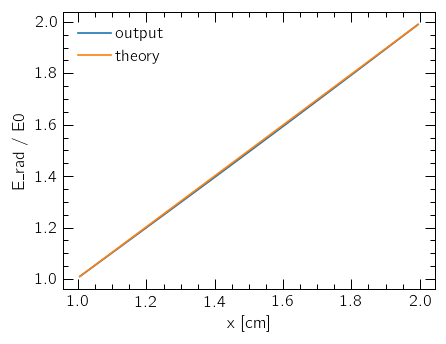

In [14]:
fig, ax = plt.subplots(figsize=(4, 3), dpi=120)

EL = 1 * E0
ER = 2 * E0

xL = grid.x1[grid.ibeg-1].to_value('cm')
xR = grid.x1[grid.iend+1].to_value('cm')

E_theo = EL + (ER-EL) / (xR-xL) * (x-xL)

ax.plot(x, fmt(Box.Er).to_value(E0), label='output')
ax.plot(x, E_theo.to_value(E0), label='theory')
ax.legend()

ax.set_xlabel('x [cm]')
ax.set_ylabel('E_rad / E0')

plt.show()

Looks pretty good, though the center seems a little off. This is not a problem, just a byproduct of the tolerance we requested from the iterative solver. We can adjust this as follows:

In [15]:
Box.solver_settings['rtol'] = 1e-12 # down from the default 1e-8

# then run some more steps
for _ in range(10): Box.advance(dt=1e0 * u.s)

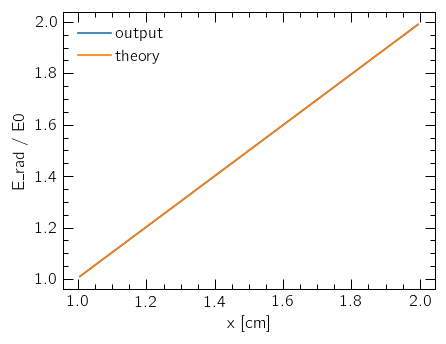

In [16]:
fig, ax = plt.subplots(figsize=(4, 3), dpi=120)

EL = 1 * E0
ER = 2 * E0

xL = grid.x1[grid.ibeg-1].to_value('cm')
xR = grid.x1[grid.iend+1].to_value('cm')

E_theo = EL + (ER-EL) / (xR-xL) * (x-xL)

ax.plot(x, fmt(Box.Er).to_value(E0), label='output')
ax.plot(x, E_theo.to_value(E0), label='theory')
ax.legend()

ax.set_xlabel('x [cm]')
ax.set_ylabel('E_rad / E0')

plt.show()

Much better agreement! In general this is not a big deal, since you will typically solve complex problems with ```pyFLD```, but if converging to an expected solution is what you're after then it might be worth reducing this tolerance as shown here.

Once you're done with this, feel free to play around with the output, or move to the 2D variant of this problem in ```radiative-sheet.ipynb```.